In [ ]:
# === Imports ===
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np
from pathlib import Path

# === Plotting Configuration ===
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# === Constants ===
DATASETS = ["youtube-sinhala-asr", "openslr-sinhala-asr", "biz-brains-academy-sinhala"]
DATASET_NAMES = [d.replace('-', ' ').title() for d in DATASETS]

MODELS = [
    "whisper-small-si-fallen-fire-29",
    "whisper-small-si-azure-river-47",
    "whisper-small-si-hardy-hill-51",
    "whisper-small-si-ruby-deluge-67"
]

# === Color Palettes ===
PALETTES = {
    'data_comparison': ['#E74C3C', '#2ECC71'],
    'youtube_impact': ['#3498DB', '#9B59B6'],
    'lora_comparison': ['#E67E22', '#16A085'],
    'multi_model': ['#3498DB', '#E67E22', '#16A085'],
    'dataset_colors': ['#FF6B6B', '#4ECDC4', '#45B7D1'],
}

# === Helper Functions ===
def get_wer_stats(dataframes, models, datasets):
    """Extract mean WER for each model across datasets."""
    wers = {m: [] for m in models}
    for dataset in datasets:
        for model in models:
            df = dataframes[f'df_{model}_{dataset}']
            wers[model].append(df['WER'].mean())
    return wers

def calculate_improvements(wers1, wers2):
    """Calculate percentage improvement between two WER lists."""
    return [((w1 - w2) / w1) * 100 for w1, w2 in zip(wers1, wers2)]

def add_bar_labels(ax, bars, fmt='{:.1f}%', fontsize=9, va='bottom'):
    """Add value labels to bar charts."""
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                fmt.format(height), ha='center', va=va, fontsize=fontsize)

def create_grouped_bar_chart(ax, x, values1, values2, labels, colors, width=0.35):
    """Create a grouped bar chart with two series."""
    bars1 = ax.bar(x - width/2, values1, width, label=labels[0], color=colors[0], alpha=0.8)
    bars2 = ax.bar(x + width/2, values2, width, label=labels[1], color=colors[1], alpha=0.8)
    add_bar_labels(ax, bars1)
    add_bar_labels(ax, bars2)
    return bars1, bars2

def create_improvement_chart(ax, improvements, dataset_names):
    """Create horizontal bar chart showing improvements."""
    bar_colors = ['#27AE60' if i > 0 else '#E74C3C' for i in improvements]
    bars = ax.barh(range(len(dataset_names)), improvements, color=bar_colors, 
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    
    for i, (bar, val) in enumerate(zip(bars, improvements)):
        offset = 0.5 if val > 0 else -0.5
        ha = 'left' if val > 0 else 'right'
        color = 'black' if val > 0 else 'white'
        ax.text(val + offset, i, f'{val:+.1f}%', va='center', ha=ha,
                fontsize=10, fontweight='bold', color=color)
    
    ax.set_yticks(range(len(dataset_names)))
    ax.set_yticklabels(dataset_names, fontsize=9)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax.grid(axis='x', alpha=0.3)
    return bars

def create_boxplot(ax, dataframes, models, datasets, colors, model_labels):
    """Create grouped boxplot for WER distribution."""
    all_data, positions = [], []
    pos = 1
    
    for dataset in datasets:
        for model in models:
            df = dataframes[f'df_{model}_{dataset}']
            all_data.append(df['WER'].values)
            positions.append(pos)
            pos += 0.8
        pos += 1.2
    
    bp = ax.boxplot(all_data, positions=positions, widths=0.6, patch_artist=True, showfliers=False)
    
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i % len(models)])
        patch.set_alpha(0.7)
    
    tick_positions = [1.4 + i * 2.8 for i in range(len(datasets))]
    ax.set_xticks(tick_positions[:len(datasets)])
    ax.set_xticklabels(DATASET_NAMES, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    legend_elements = [Patch(facecolor=colors[i], alpha=0.7, label=model_labels[i]) 
                       for i in range(len(models))]
    ax.legend(handles=legend_elements, fontsize=9)

def create_summary_table(ax, dataset_names, wers1, wers2, improvements, col_labels, 
                         header_color='#34495E', avg_color='#F39C12'):
    """Create summary statistics table."""
    ax.axis('off')
    
    table_data = [[dataset_names[i], f'{wers1[i]:.2f}%', f'{wers2[i]:.2f}%', f'{improvements[i]:+.1f}%']
                  for i in range(len(dataset_names))]
    table_data.append(['Average', f'{np.mean(wers1):.2f}%', f'{np.mean(wers2):.2f}%', 
                       f'{np.mean(improvements):+.1f}%'])
    
    table = ax.table(cellText=table_data, colLabels=col_labels, cellLoc='center', 
                     loc='center', colWidths=[0.35, 0.2, 0.2, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    for i in range(len(col_labels)):
        table[(0, i)].set_facecolor(header_color)
        table[(0, i)].set_text_props(weight='bold', color='white')
        table[(len(table_data), i)].set_facecolor(avg_color)
        table[(len(table_data), i)].set_text_props(weight='bold')
    
    ax.text(0.5, 0.78, 'Summary Statistics', ha='center', va='bottom',
            fontsize=12, fontweight='bold', transform=ax.transAxes)
    return table

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# === Base Directory (Colab) ===
_BASE_DIR = "/content/drive/MyDrive/FYP/ASR/Experiments"

# === Load All DataFrames ===
dataframes = {}
df_summary = {}

# Load WER results for each model-dataset combination
for model in MODELS:
    for dataset in DATASETS:
        csv_path = f'{_BASE_DIR}/{model}/Evaluation/{dataset}/wer_results.csv'
        dataframes[f'df_{model}_{dataset}'] = pd.read_csv(csv_path)
    
    # Load evaluation summary
    summary_path = f'{_BASE_DIR}/{model}/Evaluation/eval_summery.csv'
    if os.path.exists(summary_path):
        df_summary[f'df_{model}'] = pd.read_csv(summary_path)
    else:
        print(f'Summary not found: {summary_path}')

print(f"Loaded {len(dataframes)} WER dataframes and {len(df_summary)} summary dataframes")

✓ Visualization saved as 'simple_comparison.png'


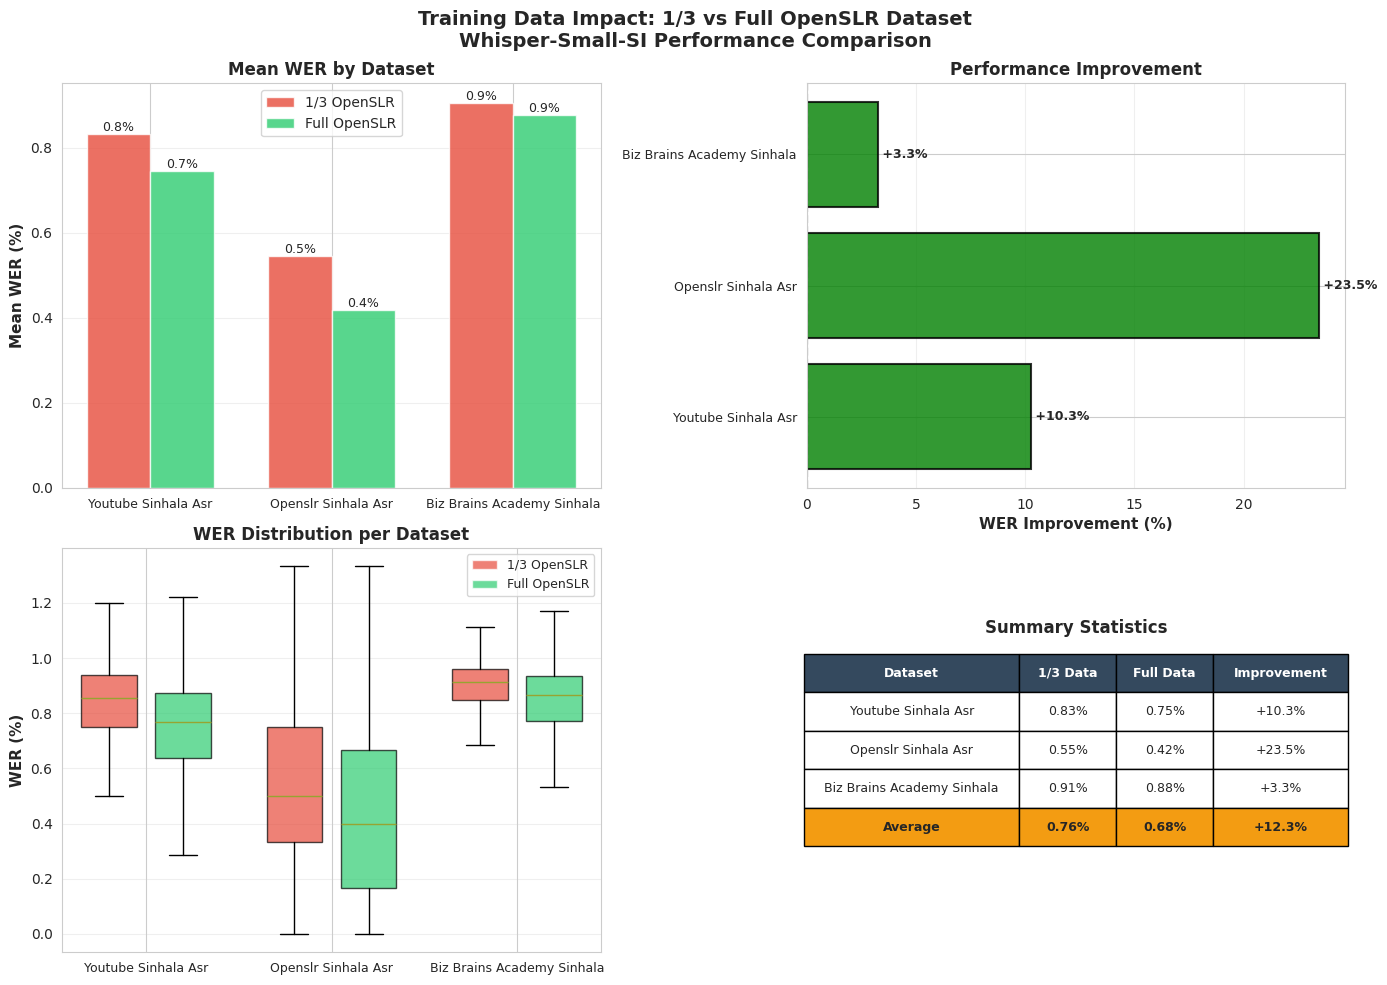

In [ ]:
# === Visualization 1: Training Data Impact (1/3 vs Full OpenSLR) ===
models = [MODELS[0], MODELS[1]]
labels = ["1/3 OpenSLR", "Full OpenSLR"]
colors = PALETTES['data_comparison']

# Get WER values
wers = get_wer_stats(dataframes, models, DATASETS)
model1_wers, model2_wers = wers[models[0]], wers[models[1]]
improvements = calculate_improvements(model1_wers, model2_wers)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bar chart
ax = axes[0, 0]
x = np.arange(len(DATASETS))
create_grouped_bar_chart(ax, x, model1_wers, model2_wers, labels, colors)
ax.set_ylabel('Mean WER (%)', fontsize=11, fontweight='bold')
ax.set_title('Mean WER by Dataset', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DATASET_NAMES, fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Improvement chart
ax = axes[0, 1]
create_improvement_chart(ax, improvements, DATASET_NAMES)
ax.set_xlabel('WER Improvement (%)', fontsize=11, fontweight='bold')
ax.set_title('Performance Improvement', fontsize=12, fontweight='bold')

# Boxplot
ax = axes[1, 0]
create_boxplot(ax, dataframes, models, DATASETS, colors, labels)
ax.set_ylabel('WER (%)', fontsize=11, fontweight='bold')
ax.set_title('WER Distribution per Dataset', fontsize=12, fontweight='bold')

# Summary table
create_summary_table(axes[1, 1], DATASET_NAMES, model1_wers, model2_wers, improvements,
                     ['Dataset', '1/3 Data', 'Full Data', 'Improvement'])

fig.suptitle('Training Data Impact: 1/3 vs Full OpenSLR Dataset\nWhisper-Small-SI Performance Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_training_data_impact_1-3_vs_full_openslr.png', dpi=300, bbox_inches='tight')
plt.show()

✓ Visualization saved as 'youtube_data_impact.png'


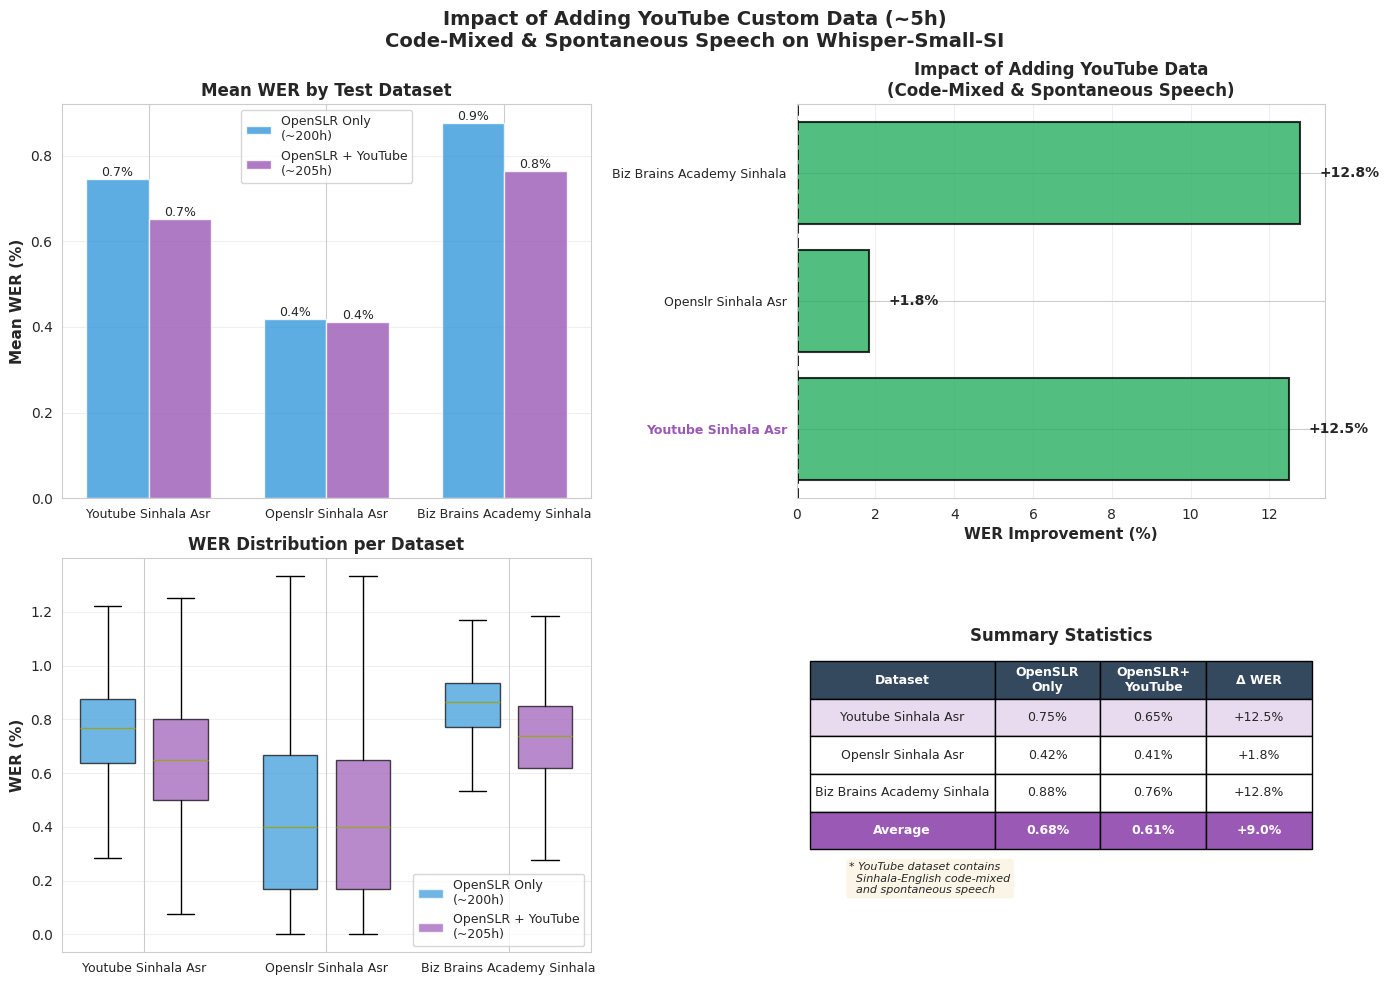

In [ ]:
# === Visualization 2: YouTube Data Impact ===
models = [MODELS[1], MODELS[2]]
labels = ["OpenSLR Only\n(~200h)", "OpenSLR + YouTube\n(~205h)"]
colors = PALETTES['youtube_impact']

# Get WER values
wers = get_wer_stats(dataframes, models, DATASETS)
model1_wers, model2_wers = wers[models[0]], wers[models[1]]
improvements = calculate_improvements(model1_wers, model2_wers)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bar chart
ax = axes[0, 0]
x = np.arange(len(DATASETS))
create_grouped_bar_chart(ax, x, model1_wers, model2_wers, labels, colors)
ax.set_ylabel('Mean WER (%)', fontsize=11, fontweight='bold')
ax.set_title('Mean WER by Test Dataset', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DATASET_NAMES, fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Improvement chart
ax = axes[0, 1]
create_improvement_chart(ax, improvements, DATASET_NAMES)
ax.set_xlabel('WER Improvement (%)', fontsize=11, fontweight='bold')
ax.set_title('Impact of Adding YouTube Data\n(Code-Mixed & Spontaneous Speech)', fontsize=12, fontweight='bold')
ax.get_yticklabels()[0].set_weight('bold')
ax.get_yticklabels()[0].set_color(colors[1])

# Boxplot
ax = axes[1, 0]
create_boxplot(ax, dataframes, models, DATASETS, colors, labels)
ax.set_ylabel('WER (%)', fontsize=11, fontweight='bold')
ax.set_title('WER Distribution per Dataset', fontsize=12, fontweight='bold')

# Summary table with note
ax = axes[1, 1]
create_summary_table(ax, DATASET_NAMES, model1_wers, model2_wers, improvements,
                     ['Dataset', 'OpenSLR\nOnly', 'OpenSLR+\nYouTube', 'Δ WER'],
                     avg_color='#9B59B6')

note_text = "* YouTube dataset contains\n  Sinhala-English code-mixed\n  and spontaneous speech"
ax.text(0.1, 0.15, note_text, fontsize=8, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

fig.suptitle('Impact of Adding YouTube Custom Data (~5h)\nCode-Mixed & Spontaneous Speech on Whisper-Small-SI',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_youtube_custom_data_impact_code_mixed_speech.png', dpi=300, bbox_inches='tight')
plt.show()

✓ Visualization saved as 'lora_config_impact.png'


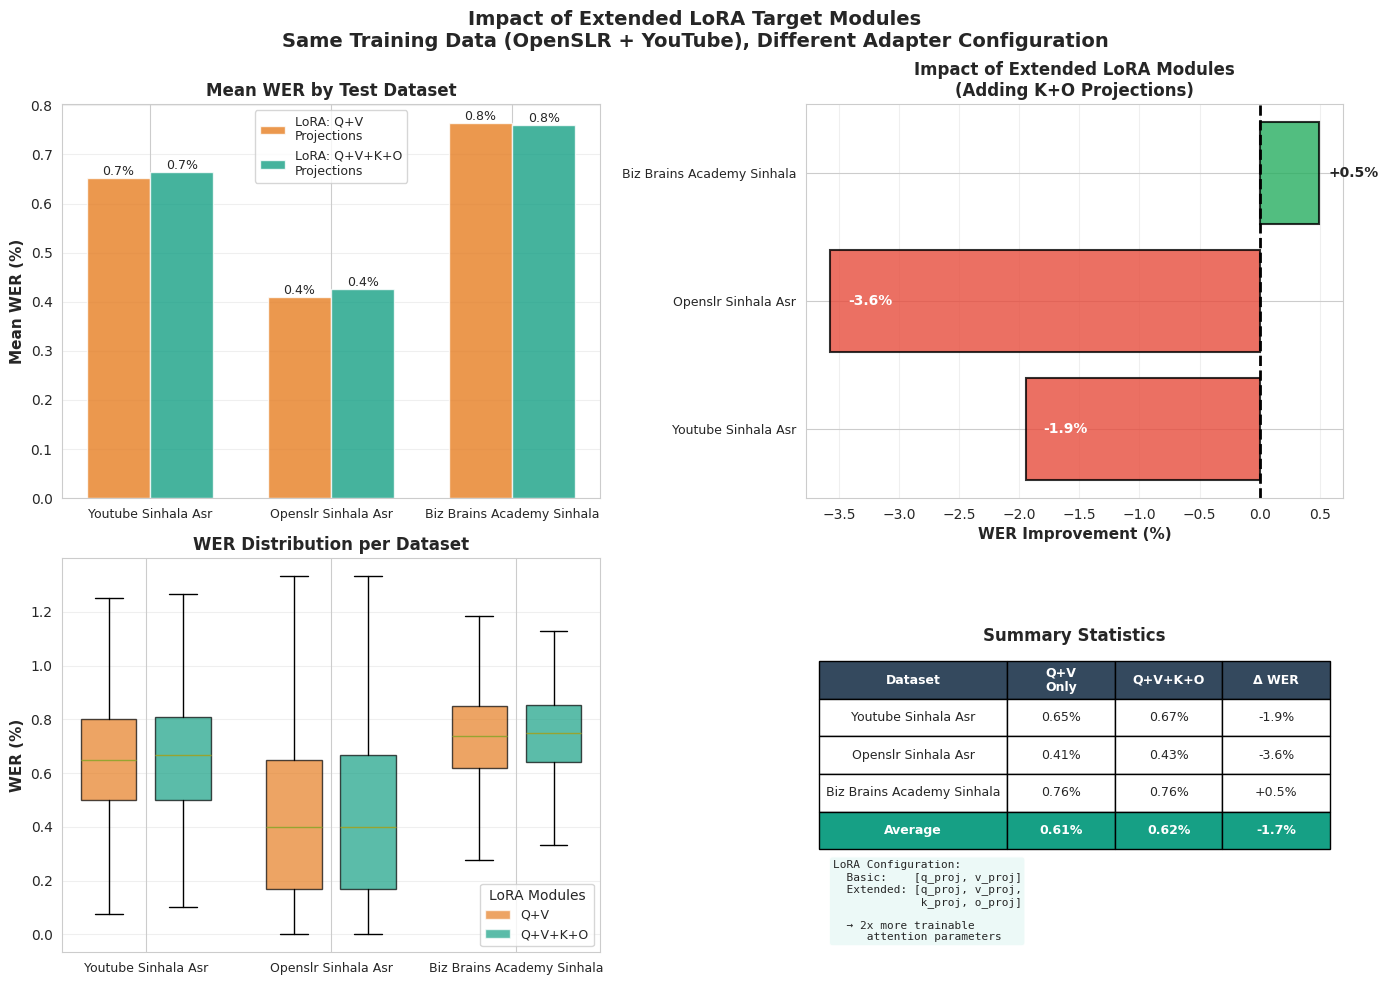

In [ ]:
# === Visualization 3: LoRA Configuration Impact ===
models = [MODELS[2], MODELS[3]]
labels = ["LoRA: Q+V\nProjections", "LoRA: Q+V+K+O\nProjections"]
colors = PALETTES['lora_comparison']

# Get WER values
wers = get_wer_stats(dataframes, models, DATASETS)
model1_wers, model2_wers = wers[models[0]], wers[models[1]]
improvements = calculate_improvements(model1_wers, model2_wers)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bar chart
ax = axes[0, 0]
x = np.arange(len(DATASETS))
create_grouped_bar_chart(ax, x, model1_wers, model2_wers, labels, colors)
ax.set_ylabel('Mean WER (%)', fontsize=11, fontweight='bold')
ax.set_title('Mean WER by Test Dataset', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DATASET_NAMES, fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Improvement chart
ax = axes[0, 1]
create_improvement_chart(ax, improvements, DATASET_NAMES)
ax.set_xlabel('WER Improvement (%)', fontsize=11, fontweight='bold')
ax.set_title('Impact of Extended LoRA Modules\n(Adding K+O Projections)', fontsize=12, fontweight='bold')

# Boxplot
ax = axes[1, 0]
create_boxplot(ax, dataframes, models, DATASETS, colors, ["Q+V", "Q+V+K+O"])
ax.set_ylabel('WER (%)', fontsize=11, fontweight='bold')
ax.set_title('WER Distribution per Dataset', fontsize=12, fontweight='bold')

# Summary table with LoRA note
ax = axes[1, 1]
create_summary_table(ax, DATASET_NAMES, model1_wers, model2_wers, improvements,
                     ['Dataset', 'Q+V\nOnly', 'Q+V+K+O', 'Δ WER'],
                     avg_color='#16A085')

lora_text = ("LoRA Configuration:\n"
             "  Basic:    [q_proj, v_proj]\n"
             "  Extended: [q_proj, v_proj,\n"
             "             k_proj, o_proj]\n\n"
             "  → 2x more trainable\n"
             "     attention parameters")
ax.text(0.05, 0.03, lora_text, fontsize=8, family='monospace',
        bbox=dict(boxstyle='round', facecolor='#E8F8F5', alpha=0.8))

fig.suptitle('Impact of Extended LoRA Target Modules\nSame Training Data (OpenSLR + YouTube), Different Adapter Configuration',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_lora_config_comparison_qv_vs_qvko_projections.png', dpi=300, bbox_inches='tight')
plt.show()

✓ Visualization saved as 'models_heatmap_trend.png'


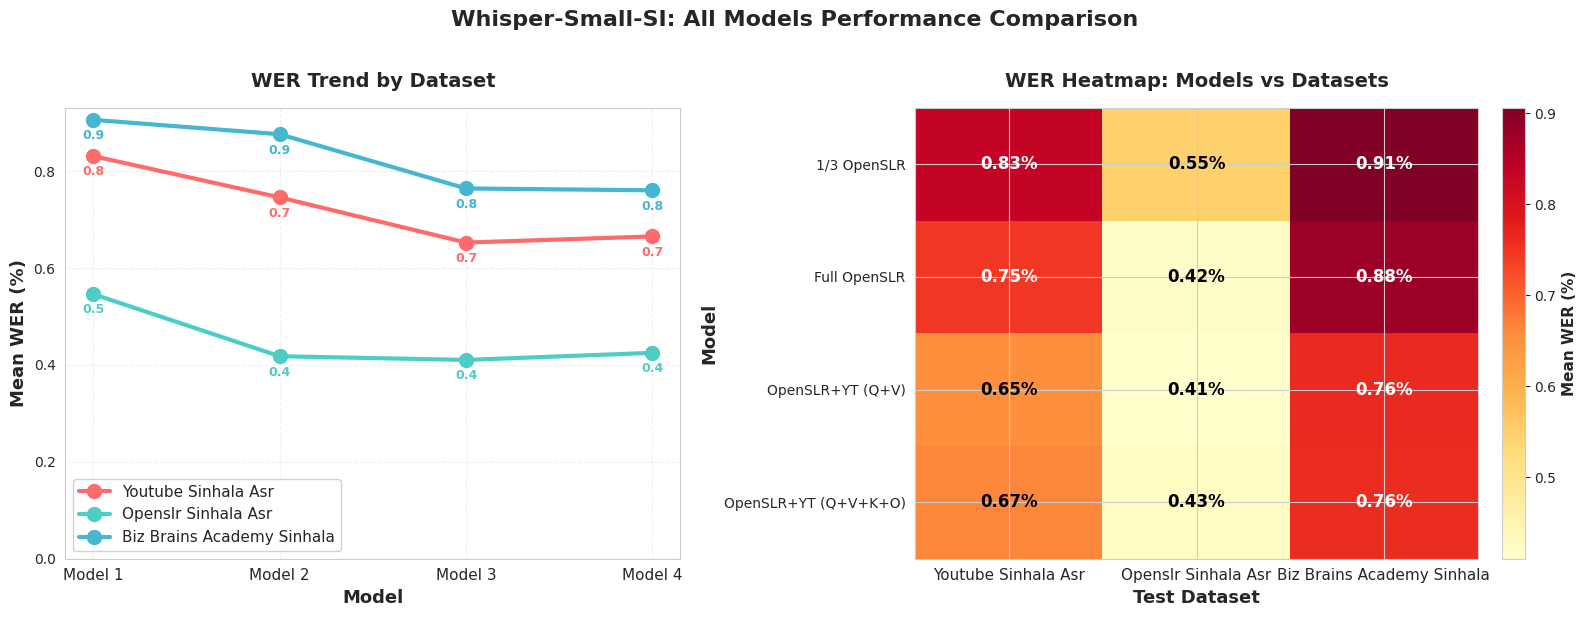

In [ ]:
# === Visualization 4: All Models Heatmap & Trend ===
model_labels = ["1/3 OpenSLR", "Full OpenSLR", "OpenSLR+YT (Q+V)", "OpenSLR+YT (Q+V+K+O)"]
colors = PALETTES['dataset_colors']

# Collect WER data for all models
all_wers = {label: [] for label in model_labels}
for dataset in DATASETS:
    for i, model in enumerate(MODELS):
        df = dataframes[f'df_{model}_{dataset}']
        all_wers[model_labels[i]].append(df['WER'].mean())

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line plot - WER trends
ax = axes[0]
for i, dataset_name in enumerate(DATASET_NAMES):
    values = [all_wers[label][i] for label in model_labels]
    ax.plot(range(4), values, 'o-', linewidth=3, markersize=10, 
            label=dataset_name, color=colors[i])
    for j, val in enumerate(values):
        ax.text(j, val - 0.04, f'{val:.1f}', ha='center', fontsize=9, 
                fontweight='bold', color=colors[i])

ax.set_xticks(range(4))
ax.set_xticklabels(['Model 1', 'Model 2', 'Model 3', 'Model 4'], fontsize=11)
ax.set_ylabel('Mean WER (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_title('WER Trend by Dataset', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(bottom=0)

# Heatmap
ax = axes[1]
heatmap_array = np.array([all_wers[label] for label in model_labels])
im = ax.imshow(heatmap_array, cmap='YlOrRd', aspect='auto',
               vmin=heatmap_array.min(), vmax=heatmap_array.max())

for i in range(len(model_labels)):
    for j in range(len(DATASETS)):
        color = "white" if heatmap_array[i, j] > heatmap_array.mean() else "black"
        ax.text(j, i, f'{heatmap_array[i, j]:.2f}%', ha="center", va="center", 
                color=color, fontsize=12, fontweight='bold')

ax.set_xticks(np.arange(len(DATASETS)))
ax.set_yticks(np.arange(len(model_labels)))
ax.set_xticklabels(DATASET_NAMES, fontsize=11)
ax.set_yticklabels(model_labels, fontsize=10)
ax.set_xlabel('Test Dataset', fontsize=13, fontweight='bold')
ax.set_ylabel('Model', fontsize=13, fontweight='bold')
ax.set_title('WER Heatmap: Models vs Datasets', fontsize=14, fontweight='bold', pad=15)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Mean WER (%)', fontsize=11, fontweight='bold')

fig.suptitle('Whisper-Small-SI: All Models Performance Comparison',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_all_models_wer_heatmap_and_trend_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipython-input-423847240.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Additional metrics visualization saved!


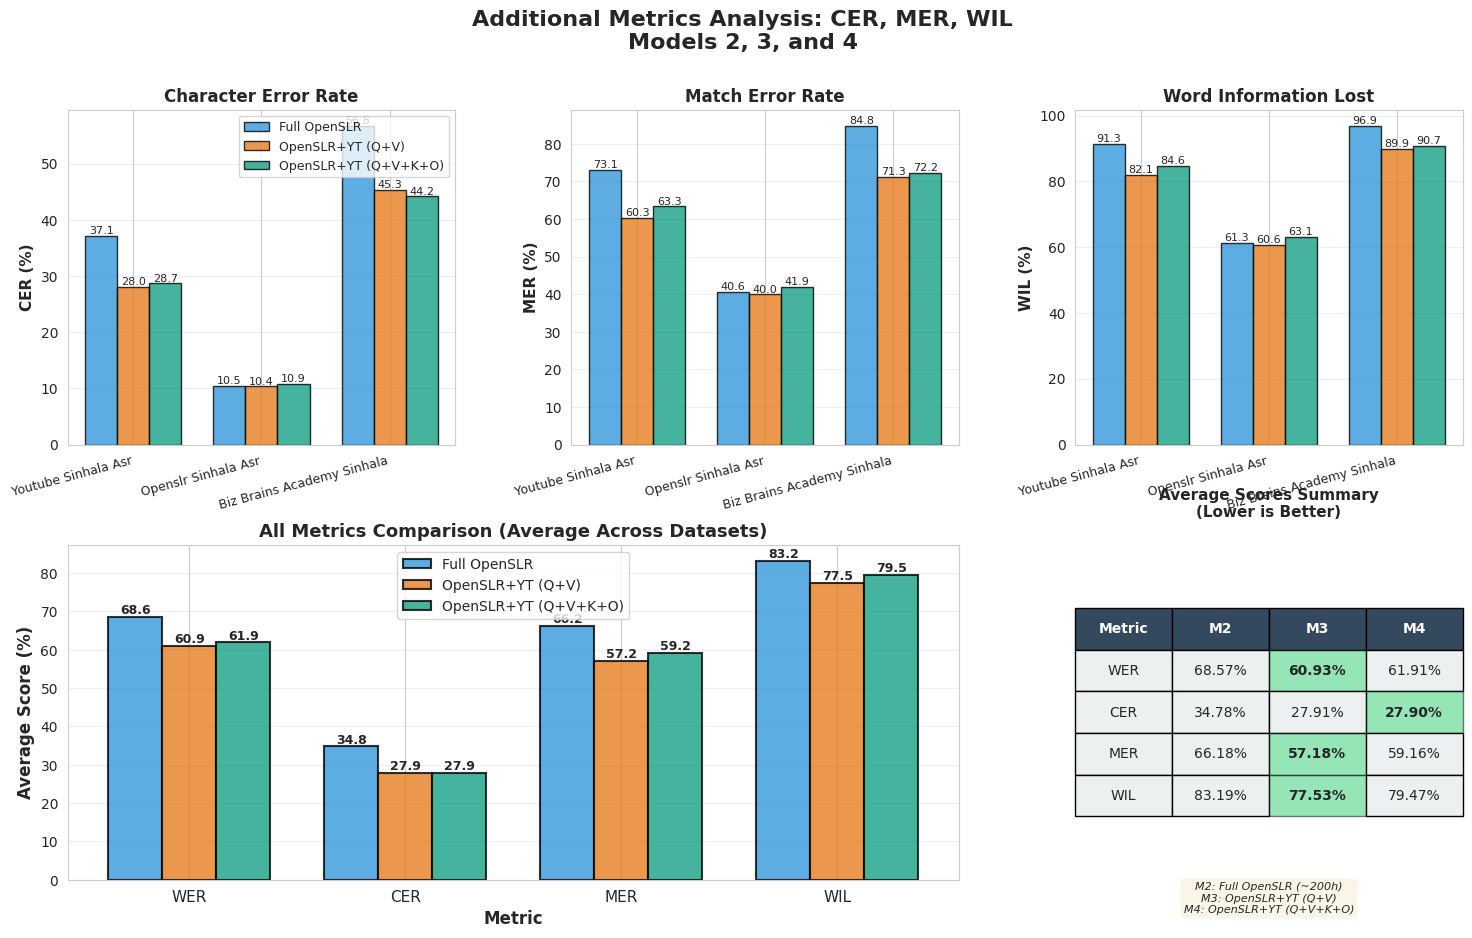

In [ ]:
# === Visualization 5: Additional Metrics (CER, MER, WIL) ===
models = MODELS[1:4]  # Models 2, 3, 4
model_labels = ["Full OpenSLR", "OpenSLR+YT (Q+V)", "OpenSLR+YT (Q+V+K+O)"]
colors = PALETTES['multi_model']
metrics = ['WER', 'CER', 'MER', 'WIL']

# Extract metrics data
metrics_data = {m: [] for m in metrics}
for metric in [m.lower() for m in metrics]:
    for model in models:
        df = df_summary[f'df_{model}']
        values = [row[metric] * 100 for _, row in df.iterrows() if row['dataset'] != 'AVERAGE']
        metrics_data[metric.upper()].append(values)

# Get dataset names from summary
first_df = df_summary[f'df_{models[0]}']
summary_dataset_names = [row['dataset'].split('/')[-1].replace('-', ' ').title() 
                         for _, row in first_df.iterrows() if row['dataset'] != 'AVERAGE']

# Create figure
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

metric_titles = {'CER': 'Character Error Rate', 'MER': 'Match Error Rate', 'WIL': 'Word Information Lost'}

# Individual metric charts (CER, MER, WIL)
for idx, metric in enumerate(['CER', 'MER', 'WIL']):
    ax = fig.add_subplot(gs[0, idx])
    x = np.arange(len(summary_dataset_names))
    width = 0.25
    
    for i, (label, color) in enumerate(zip(model_labels, colors)):
        offset = width * (i - 1)
        bars = ax.bar(x + offset, metrics_data[metric][i], width, label=label,
                      color=color, alpha=0.8, edgecolor='black', linewidth=1)
        add_bar_labels(ax, bars, fmt='{:.1f}', fontsize=8)
    
    ax.set_ylabel(f'{metric} (%)', fontsize=11, fontweight='bold')
    ax.set_title(metric_titles[metric], fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(summary_dataset_names, fontsize=9, rotation=15, ha='right')
    if idx == 0:
        ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

# Average metrics comparison
ax = fig.add_subplot(gs[1, :2])
avg_metrics = {label: [np.mean(metrics_data[m][i]) for m in metrics] for i, label in enumerate(model_labels)}
x = np.arange(len(metrics))
width = 0.25

for i, (label, color) in enumerate(zip(model_labels, colors)):
    offset = width * (i - 1)
    bars = ax.bar(x + offset, avg_metrics[label], width, label=label,
                  color=color, alpha=0.8, edgecolor='black', linewidth=1.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Average Score (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax.set_title('All Metrics Comparison (Average Across Datasets)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Summary table
ax = fig.add_subplot(gs[1, 2])
ax.axis('off')

table_data = [[m] + [f'{np.mean(metrics_data[m][i]):.2f}%' for i in range(3)] for m in metrics]
table = ax.table(cellText=table_data, colLabels=['Metric', 'M2', 'M3', 'M4'],
                 cellLoc='center', loc='center', colWidths=[0.25]*4)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header
for i in range(4):
    table[(0, i)].set_facecolor('#34495E')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Highlight best values
for row_idx in range(1, len(metrics) + 1):
    values = [float(table_data[row_idx-1][j].replace('%', '')) for j in range(1, 4)]
    best_col = values.index(min(values)) + 1
    for col in range(4):
        if col == best_col:
            table[(row_idx, col)].set_facecolor('#2ECC71')
            table[(row_idx, col)].set_text_props(weight='bold')
        else:
            table[(row_idx, col)].set_facecolor('#ECF0F1')

ax.set_title('Average Scores Summary\n(Lower is Better)', fontsize=11, fontweight='bold', pad=20)
ax.text(0.5, -0.1, "M2: Full OpenSLR (~200h)\nM3: OpenSLR+YT (Q+V)\nM4: OpenSLR+YT (Q+V+K+O)",
        ha='center', fontsize=8, style='italic', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

fig.suptitle('Additional Metrics Analysis: CER, MER, WIL\nModels 2, 3, and 4', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('05_additional_metrics_cer_mer_wil_comparison.png', dpi=300, bbox_inches='tight')
plt.show()